In [90]:
import sympy as sp              # para álgebra simbólica (integración, derivación, ecuaciones)
import numpy as np              # para operaciones numéricas y crear arrays de datos
import matplotlib.pyplot as plt # para crear visualizaciones y gráficos
import numpy_financial as nf
import pandas as pd             # para manipulación y análisis de datos

# Ejercicio 1

A partir del cash flow MENSUAL establecido en la línea de código propuesta a continuación y considerando un costo de capital anual del 9% ,realice un análisis que contenga:

1- Métricas financieras: VAN, TIR, TIRM y PAYBACK DESCONTADO e interprete cada una de ellas.


2- Grafique el Van a diferentes tasas de descuento de costo del capital (marque en dicho gráfico la TIR y explíquelo)

3- Considere que el gerente financiero pronostica un aumento posible del costo de capital a la hora de iniciar el proyecto conformando un costo total del 21% anual. Interprete los resultados del nuevo análisis y haga un gráfico comparativo de ambas situaciones.

In [91]:
inversion_inicial = -70000
cash_flows = [
    13000, -10500, -10000, 18000, 25800, -22000, 27000, 18000, -27000, 29000,
    15000, -10000, 10000, -18000, 20000, -21000, 24000, -27000, 28000, -10000,
    -8000, 40000, 18000, -13000, 25000, 18000, -26000, 25000, 42000
]
nuevo_cash_flow = [inversion_inicial] + cash_flows
r = 0.09 / 12  # dado que es tasa nominal y no efectiva anual uso división simple o no por equivalencia

### 1.1 Métricas financieras

In [92]:
# VAN
van = nf.npv(rate=r, values=nuevo_cash_flow)
print(f"VAN: {van:.2f}")

VAN: 98116.48


In [93]:
# TIR
tir = nf.irr(values=nuevo_cash_flow)
print(f"TIR mensual: {tir:.6f}")
print(f"TIR anual: {(1 + tir)**12 - 1:.6f}")

TIR mensual: 0.065057
TIR anual: 1.130460


In [94]:
# TIRM
# finance_rate: costo de financiar flujos negativos (costo de capital)
# reinvest_rate: tasa de reinversión de flujos positivos (costo de oportunidad)
tirm = nf.mirr(values=nuevo_cash_flow, finance_rate=r, reinvest_rate=r)

print(f"TIRM mensual: {tirm:.6f}")
print(f"TIRM anual: {(1 + tirm)**12 - 1:.6f}")

TIRM mensual: 0.019007
TIRM anual: 0.253498


In [95]:
def payback_desc(cfs, rate, c0):
    acum_desc = c0  # Empezar con la inversión inicial (negativa)
    prd = None
    for t in range(1, len(cfs)):  # Empezar desde t=1 (primer flujo operativo)
        fc_desc = cfs[t] / (1 + rate)**t
        acum_desc += fc_desc
        if acum_desc >= 0 and prd is None:
            # interpolación
            prd = (t - 1) + (0 - (acum_desc - fc_desc)) / fc_desc
            break
    return prd

In [96]:
# payback descontado
prd = payback_desc(cash_flows, r, inversion_inicial)
print(f"Payback descontado: {prd:.2f} meses")

Payback descontado: 20.62 meses


### 1.2 Grafique el VAN a diferentes tasas de descuento

Tasa Interna de Retorno (TIR): 6.51%
Tasa Interna de Retorno Modificada (TIRM): 1.90%


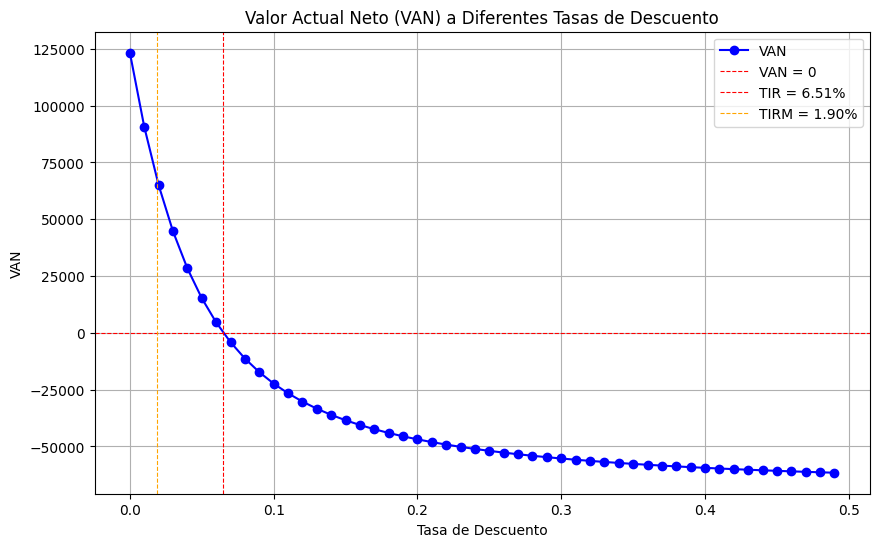

In [97]:
# --- Calcular TIR y TIRM ---
flujos = nuevo_cash_flow.copy()
# tir = nf.irr(flujos)
# tirm = nf.mirr(flujos, rfinanciamiento, rreinversion)

print(f"Tasa Interna de Retorno (TIR): {tir:.2%}")
print(f"Tasa Interna de Retorno Modificada (TIRM): {tirm:.2%}")

# --- Crear rango de tasas para VAN ---
tasas_descuento = np.arange(0, max(tir*1.2, 0.5), 0.01) # es muy importante agregar el max porque sino el grafico no encuentra el corte con la tir, queda desescalado.
# --- Calcular VAN para cada tasa ---
van_por_tasa = [nf.npv(tasa, flujos) for tasa in tasas_descuento]

# --- Graficar VAN vs Tasa ---
plt.figure(figsize=(10, 6))
plt.plot(tasas_descuento, van_por_tasa, marker='o', linestyle='-', color='blue', label='VAN')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8, label='VAN = 0')

# Marcar TIR y TIRM en el gráfico
plt.axvline(tir, color='red', linestyle='--', linewidth=0.8, label=f"TIR = {tir:.2%}")
plt.axvline(tirm, color='orange', linestyle='--', linewidth=0.8, label=f"TIRM = {tirm:.2%}")

# --- Etiquetas y formato ---
plt.title('Valor Actual Neto (VAN) a Diferentes Tasas de Descuento')
plt.xlabel('Tasa de Descuento')
plt.ylabel('VAN')
plt.grid(True)
plt.legend()
plt.show()


### 1.3 Nuevo costo

In [98]:
r2 = 0.21 / 12  # Convertir tasa anual a mensual
van2 = nf.npv(rate=r2, values=nuevo_cash_flow)
tir2 = nf.irr(values=nuevo_cash_flow)  # TIR no cambia (característica del proyecto)
tirm2 = nf.mirr(values=nuevo_cash_flow, finance_rate=r2, reinvest_rate=r2)
prd2 = payback_desc(cash_flows, r2, inversion_inicial)

In [99]:
print(f"VAN con nueva tasa de descuento ({r2:.2%}): {van2:.2f}")
print(f"TIR con nueva tasa de descuento: {tir2:.2%}")
print(f"TIRM con nueva tasa de descuento: {tirm2:.2%}")
print(f"Payback descontado con nueva tasa de descuento: {prd2:.2f} meses")

VAN con nueva tasa de descuento (1.75%): 70878.54
TIR con nueva tasa de descuento: 6.51%
TIRM con nueva tasa de descuento: 2.70%
Payback descontado con nueva tasa de descuento: 20.87 meses


In [100]:
# Crear cuadro comparativo de métricas financieras
comparacion_data = {
    'Métrica': ['VAN', 'TIR', 'TIRM', 'Payback Desc.'],
    'K0 9% anual': [f"${van:,.2f}", f"{tir:.2%}", f"{tirm:.2%}", f"{prd:.2f} meses"],
    'K0 21% anual': [f"${van2:,.2f}", f"{tir2:.2%}", f"{tirm2:.2%}", f"{prd2:.2f} meses"],
    'Diferencia': [f"${van - van2:,.2f}", "Sin cambio", f"{tirm2 - tirm:.2%}", f"{prd2 - prd:.2f} meses"]
}

df_comparacion = pd.DataFrame(comparacion_data)
print("CUADRO COMPARATIVO DE MÉTRICAS FINANCIERAS")
print("=" * 60)
print(df_comparacion.to_string(index=False))

# Interpretación adicional
print("\n" + "=" * 60)
print("INTERPRETACIÓN:")
print(f"• El VAN disminuye en ${van - van2:,.2f} al aumentar el costo de capital")
print(f"• La TIR se mantiene constante en {tir:.2%} (es una característica intrínseca del proyecto)")
print(f"• La TIRM aumenta de {tirm:.2%} a {tirm2:.2%}: comportamiento contra-intuitivo pero correcto.")
print(f"  Este proyecto tiene {sum(1 for fc in cash_flows if fc < 0)} flujos negativos intermedios (de {len(cash_flows)} períodos).")
print(f"  Al aumentar la tasa de descuento, el VA de esos flujos negativos disminuye (valen 'menos'),")
print(f"  reduciendo el denominador de la fórmula MIRR = [(VF_positivos/VA_negativos)^(1/n)-1] y aumentando la TIRM.")
print(f"• El Payback descontado aumenta levemente de {prd:.2f} a {prd2:.2f} meses (+{prd2-prd:.2f} meses).")
print(f"  La similitud se debe a que los primeros flujos positivos grandes (meses 1, 4, 5) compensan rápidamente")
print(f"  la inversión inicial, y el efecto del descuento es menor en períodos cercanos (factor 1/(1+r)^t).")
print(f"• Con costo del 21% anual ({r2:.4%} mensual), el proyecto {'NO ES' if van2 < 0 else 'ES'} VIABLE (VAN {'negativo' if van2 < 0 else 'positivo'})")

CUADRO COMPARATIVO DE MÉTRICAS FINANCIERAS
      Métrica K0 9% anual K0 21% anual Diferencia
          VAN  $98,116.48   $70,878.54 $27,237.94
          TIR       6.51%        6.51% Sin cambio
         TIRM       1.90%        2.70%      0.80%
Payback Desc. 20.62 meses  20.87 meses 0.25 meses

INTERPRETACIÓN:
• El VAN disminuye en $27,237.94 al aumentar el costo de capital
• La TIR se mantiene constante en 6.51% (es una característica intrínseca del proyecto)
• La TIRM aumenta de 1.90% a 2.70%: comportamiento contra-intuitivo pero correcto.
  Este proyecto tiene 12 flujos negativos intermedios (de 29 períodos).
  Al aumentar la tasa de descuento, el VA de esos flujos negativos disminuye (valen 'menos'),
  reduciendo el denominador de la fórmula MIRR = [(VF_positivos/VA_negativos)^(1/n)-1] y aumentando la TIRM.
• El Payback descontado aumenta levemente de 20.62 a 20.87 meses (+0.25 meses).
  La similitud se debe a que los primeros flujos positivos grandes (meses 1, 4, 5) compensan rápida